In [ ]:
import pandas as pd

In [ ]:
df = pd.read_excel('../data/Relatório de Produção - Completo - Dados.xlsx')

In [ ]:
df

In [ ]:
df.columns = df.iloc[1]
df = df.iloc[2:].reset_index(drop=True)
df.columns.name = None

In [ ]:
df

In [ ]:
df.columns

# Percentual Objetivo

In [ ]:
objetivo = df['Qtd Objetivo'].astype(float) / df['Qtd Teorica Real'].astype(float) * 100
objetivo

In [ ]:
df.info()

In [ ]:
colunas_float = [
    "Eficiencia Plan",
    "Hora Hora Wht (6to6)",
    "Veloc Stand",
    "Veloc Real",
    "Qtd Teorica Real",
    "Corte de Gota %",
    "Objetivo %",
    "Qtd Objetivo",
    "Empacotado %",
    "Qtd Empacotado",
    "Qtd Rejeicao",
    "Rejeição %",
]

for coluna in colunas_float:
    df[coluna] = pd.to_numeric(
        df[coluna]
        .astype("string")
        .str.strip()
        .str.replace("%", "", regex=False)
        .str.replace(",", ".", regex=False),
        errors="coerce",
    )

In [ ]:
df

# Desempenho Hora a Hora 

In [ ]:
tabela = df[
    ["Maquina", "Hora Hora Wht (6to6)", "Objetivo %", "Empacotado %"]
].copy()

tabela["Desempenho Hora"] = (
    tabela["Empacotado %"] - tabela["Objetivo %"]
)

tabela

# Desempenho Diário

- Objetivo mesmo para todos
- Média empacotado por dia

Desempenho Diário = Objetivo % - Média Diária por Máquina do Empacotado

In [ ]:
desempenho_empacotamento_diario = df.groupby(["Maquina", "Prefixo"]).agg({'Objetivo %': 'min', 'Empacotado %': 'mean', 'Rejeição %': 'mean'})

# Empacotado Rejeitado

Empacotado Rejeitado = Empacotado - Rejeitado % 

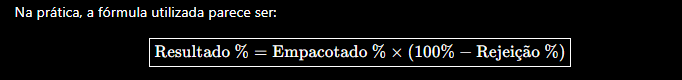

In [ ]:
desempenho_empacotamento_diario["Emp - Rejeitado %"] = (
    desempenho_empacotamento_diario["Empacotado %"]
    * (1 - desempenho_empacotamento_diario["Rejeição %"])
)

In [ ]:
desempenho_empacotamento_diario

In [ ]:
desempenho_empacotamento_diario.to_excel('../data/desempenho_empacotamento_diario.xlsx', index=True)

## Desempenho Hora a Hora

In [ ]:
df['Hora Hora Wht (6to6)']

In [ ]:
import plotly.express as px

In [ ]:
desempenho_hora_hora = (
    df.groupby(
        ["Maquina", "Hora Hora Wht (6to6)", "Prefixo"],
        as_index=False,
    )
    .agg({
        "Objetivo %": "max",
        "Empacotado %": "max",
        "Rejeição %": "mean",
    })
)

In [ ]:
desempenho_hora_hora

In [ ]:
# O DataFrame agrupado já está no formato necessário para o gráfico.
desempenho_grafico = desempenho_hora_hora.copy()

In [ ]:
for maquina in desempenho_grafico["Maquina"].dropna().unique():
    dados_maquina = (
        desempenho_grafico[desempenho_grafico["Maquina"] == maquina]
        .sort_values("Hora Hora Wht (6to6)")
    )

    figura = px.line(
        dados_maquina,
        x="Hora Hora Wht (6to6)",
        y="Empacotado %",
        color="Prefixo",
        markers=True,
        title=f"Desempenho Hora a Hora — Máquina {maquina}",
        labels={
            "Hora Hora Wht (6to6)": "Hora",
            "Empacotado %": "Percentual empacotado",
            "Prefixo": "Prefixo",
        },
    )

    objetivo_maquina = (
        dados_maquina.groupby("Hora Hora Wht (6to6)", as_index=False)
        .agg({"Objetivo %": "max"})
        .sort_values("Hora Hora Wht (6to6)")
    )

    figura.add_scatter(
        x=objetivo_maquina["Hora Hora Wht (6to6)"],
        y=objetivo_maquina["Objetivo %"],
        mode="lines",
        name="Objetivo",
        line={"color": "#2ab72a", "width": 2},
        hovertemplate="Hora=%{x}<br>Objetivo=%{y:.2%}<extra></extra>",
    )

    figura.show()